In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from hotelling.stats import hotelling_t2

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [56]:
## PCA with filtered & scaled Data

In [57]:
cd C:\Users\tr432\Downloads\Metabolomics_GutLungAxis_re-pipeline

C:\Users\tr432\Downloads\Metabolomics_GutLungAxis_re-pipeline


In [58]:
def plot_confidence_ellipse(data, confidence_level=0.90):
    # 중심점 계산
    mean_x, mean_y = np.mean(data, axis=0)
    
    # 공분산 행렬 계산
    cov_matrix = np.cov(data, rowvar=False)
    
    # 고유값 분해
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)
    
    # 신뢰도 수준 스케일링
    # 90% 신뢰 구간을 위해 chi-square 값의 제곱근을 사용 (2차원에서는 약 4.605)
    if confidence_level == 0.95 :
        chi_square_val = 5.991
    elif confidence_level == 0.90 :
        chi_square_val = 4.605
    elif confidence_level == 0.8 :
        chi_square_val = 3.219
    else:
        raise ValueError('CI')

    scale = np.sqrt(chi_square_val)
    
    # 반지름 계산
    width, height = 2 * scale * np.sqrt(eigvals)
    
    # 타원의 회전각 계산 (라디안에서 도 단위로 변환)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    return (mean_x, mean_y), width, height, angle

def cal_ellipse(data, group_name, component1='Component1', componet2='Component2', cl=0.9):
    data = data[data['Group'] == group_name]
    data = data[[component1, componet2]].values

    (mean_x, mean_y), width, height, angle = plot_confidence_ellipse(data, confidence_level=cl)

    return (mean_x, mean_y), width, height, angle

In [59]:
STYPE = 'fecal_pos'
WEEK = '2'

group1 = 'Control'
group2 = 'VNAM'

In [60]:
df = pd.read_excel("dataset_filtered_scaled_merged.xlsx", sheet_name=f'{STYPE}_{WEEK}w', index_col="Label")
df = df.transpose()
df

Label,Group,132.10187-1.793,86.09628-1.791,265.1118-1.078,166.08621-3.166,60.04447-16.937,132.10193-1.494,297.27878-16.919,120.08073-3.155,337.12751-8.427,...,182.19021-13.573,171.0652-7.474,197.09212-7.014,311.18556-13.449,83.04907-17.088,209.11695-12.53,152.11821-17.7,171.13801-10.682,141.14676-17.763,179.16241-17.614
C01_2w,Control,0.392991,0.536194,0.071708,0.382719,-1.983627,2.523484,1.360002,0.386571,-1.249098,...,-0.602145,-1.212609,-0.006968,0.773509,1.299329,0.373579,-0.923484,-1.670024,-1.215653,-0.701468
C02_2w,Control,0.65973,0.771044,0.24569,0.671552,2.152073,0.489079,1.212325,0.67914,-1.135278,...,-0.602145,1.349567,-0.03654,1.355301,1.828066,-0.868033,-0.923484,-1.670024,-1.215653,2.577924
C03_2w,Control,0.513324,0.631771,0.550086,0.489937,2.142572,0.11877,1.572046,0.483028,-1.052404,...,2.446063,1.6541,1.224661,-1.221628,-1.331975,-0.139865,-0.923484,0.656953,-1.215653,-0.701468
C04_2w,Control,0.818911,0.885933,0.390955,0.834238,-1.983627,0.661242,1.176848,0.83736,-1.070057,...,-0.602145,1.907133,0.743655,2.293875,-1.331975,-0.240219,-0.923484,1.000148,1.353348,2.526132
C05_2w,Control,0.863389,0.937035,0.411187,0.902039,-1.983627,0.724183,1.361825,0.898057,-1.049341,...,-0.602145,1.938297,0.290824,0.925729,-1.331975,-0.14021,1.644572,1.336359,1.546331,-0.701468
C06_2w,Control,0.748013,0.819389,0.335498,0.778327,2.092571,0.417435,1.215329,0.767732,-1.059208,...,-0.602145,-1.212609,0.242247,1.239619,-1.331975,-0.010023,-0.923484,-1.670024,1.27425,-0.701468
C07_2w,Control,0.511128,0.611852,0.212719,0.440245,2.188845,0.223336,0.873096,0.427592,-1.097809,...,2.586506,1.608846,-0.236471,-1.221628,-1.331975,1.054662,-0.923484,0.560271,-1.215653,-0.701468
C08_2w,Control,0.526539,-1.187623,0.571052,0.52269,-1.983627,0.387108,1.701579,0.535114,-1.042859,...,-0.602145,0.701541,0.657485,-1.221628,1.615198,-0.097752,0.934992,0.950408,-1.215653,2.238253
C09_2w,Control,0.42652,0.579992,0.495131,0.423647,2.01026,0.247672,1.345589,0.431614,-1.065118,...,2.950036,-1.212609,0.233278,-1.221628,0.450231,0.603985,2.286603,-1.670024,0.570047,-0.701468
C10_2w,Control,0.035653,-2.288848,0.258545,-0.049293,2.201919,-0.268858,1.219748,-0.045708,-1.15612,...,-0.602145,-1.212609,0.21974,-1.221628,-1.331975,0.383723,2.045504,1.594336,1.604151,-0.701468


In [61]:
df = df[df["Group"] != "QC"].copy()  #Edit: 주석처리 하거나 풀거나
df

Label,Group,132.10187-1.793,86.09628-1.791,265.1118-1.078,166.08621-3.166,60.04447-16.937,132.10193-1.494,297.27878-16.919,120.08073-3.155,337.12751-8.427,...,182.19021-13.573,171.0652-7.474,197.09212-7.014,311.18556-13.449,83.04907-17.088,209.11695-12.53,152.11821-17.7,171.13801-10.682,141.14676-17.763,179.16241-17.614
C01_2w,Control,0.392991,0.536194,0.071708,0.382719,-1.983627,2.523484,1.360002,0.386571,-1.249098,...,-0.602145,-1.212609,-0.006968,0.773509,1.299329,0.373579,-0.923484,-1.670024,-1.215653,-0.701468
C02_2w,Control,0.65973,0.771044,0.24569,0.671552,2.152073,0.489079,1.212325,0.67914,-1.135278,...,-0.602145,1.349567,-0.03654,1.355301,1.828066,-0.868033,-0.923484,-1.670024,-1.215653,2.577924
C03_2w,Control,0.513324,0.631771,0.550086,0.489937,2.142572,0.11877,1.572046,0.483028,-1.052404,...,2.446063,1.6541,1.224661,-1.221628,-1.331975,-0.139865,-0.923484,0.656953,-1.215653,-0.701468
C04_2w,Control,0.818911,0.885933,0.390955,0.834238,-1.983627,0.661242,1.176848,0.83736,-1.070057,...,-0.602145,1.907133,0.743655,2.293875,-1.331975,-0.240219,-0.923484,1.000148,1.353348,2.526132
C05_2w,Control,0.863389,0.937035,0.411187,0.902039,-1.983627,0.724183,1.361825,0.898057,-1.049341,...,-0.602145,1.938297,0.290824,0.925729,-1.331975,-0.14021,1.644572,1.336359,1.546331,-0.701468
C06_2w,Control,0.748013,0.819389,0.335498,0.778327,2.092571,0.417435,1.215329,0.767732,-1.059208,...,-0.602145,-1.212609,0.242247,1.239619,-1.331975,-0.010023,-0.923484,-1.670024,1.27425,-0.701468
C07_2w,Control,0.511128,0.611852,0.212719,0.440245,2.188845,0.223336,0.873096,0.427592,-1.097809,...,2.586506,1.608846,-0.236471,-1.221628,-1.331975,1.054662,-0.923484,0.560271,-1.215653,-0.701468
C08_2w,Control,0.526539,-1.187623,0.571052,0.52269,-1.983627,0.387108,1.701579,0.535114,-1.042859,...,-0.602145,0.701541,0.657485,-1.221628,1.615198,-0.097752,0.934992,0.950408,-1.215653,2.238253
C09_2w,Control,0.42652,0.579992,0.495131,0.423647,2.01026,0.247672,1.345589,0.431614,-1.065118,...,2.950036,-1.212609,0.233278,-1.221628,0.450231,0.603985,2.286603,-1.670024,0.570047,-0.701468
C10_2w,Control,0.035653,-2.288848,0.258545,-0.049293,2.201919,-0.268858,1.219748,-0.045708,-1.15612,...,-0.602145,-1.212609,0.21974,-1.221628,-1.331975,0.383723,2.045504,1.594336,1.604151,-0.701468


In [62]:
# 1) y, X 분리
y = df.iloc[:, 0].astype(str)     # Group
X = df.iloc[:, 1:].copy()         # peak area들

# 2) ✅ 이번 에러 핵심: 컬럼명이 str/float 섞임 → 전부 문자열로 통일
X.columns = X.columns.map(str)

# (선택) 비정상 헤더 제거(빈 헤더/Unnamed가 섞인 경우)
X = X.loc[:, ~X.columns.str.match(r"^Unnamed")]
X = X.loc[:, X.columns != "nan"]

# 3) 숫자화 + 결측 처리
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")                 # 전부 NA인 feature 제거
X = X.fillna(X.median(numeric_only=True))       # 중앙값 대치

# 4) (선택) 스케일링 (스케일링을 안한 데이터라면)
#Xz = StandardScaler().fit_transform(X)
Xz = X.copy()

In [63]:
# 5) PCA
pca = PCA(n_components=2, random_state=0)
PC = pca.fit_transform(Xz)
pc1, pc2 = PC[:, 0], PC[:, 1]
evr = pca.explained_variance_ratio_ * 100

In [64]:
# k 선택: 예) 누적 설명분산 80%까지
pca_full = PCA(n_components=min(X.shape[0]-1, X.shape[1]), random_state=0)
PC_all = pca_full.fit_transform(Xz)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k = int(np.searchsorted(cum, 0.80) + 1)   # 80% 기준 (원하면 0.90 등으로 변경)

PCk = PC_all[:, :k]  # PC1..PCk

# Control/VNAM만
mask = y.isin([group1, group2]).values
labs = y.values[mask]
Z = PCk[mask]

Zc = Z[labs == group1]
Zv = Z[labs == group2]

# 조건: (각 그룹 n > k) & (n1+n2-2 > k) 정도는 만족해야 안정적
t2, fval, p_group, S = hotelling_t2(Zc, Zv)

p_txt = f'{p_group:.3e}' if p_group < 0.001 else f'{p_group:.3f}'
p_title = f'{group1} vs. {group2} : p = {p_txt}\n(Week {WEEK}; n = {mask.sum()})'

print(f'PC 1 ~ PC {k} = {cum[k-1]*100:.2f} %')

PC 1 ~ PC 9 = 80.81 %


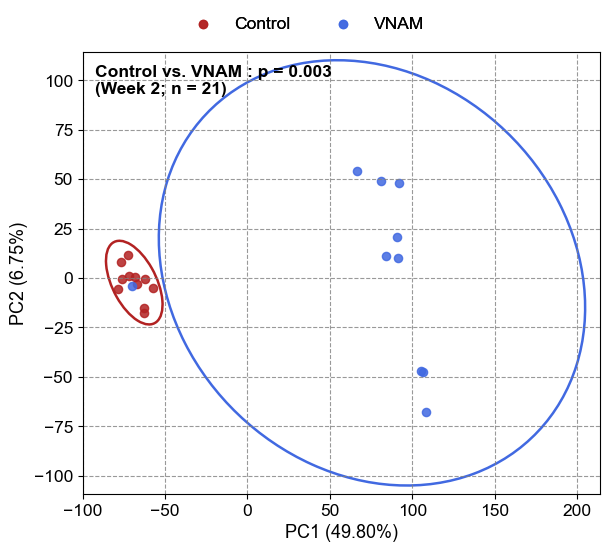

In [65]:
# 6) Plot
# cal_ellipse가 요구하는 형태로 score df 생성
pc_df = pd.DataFrame({"Component1": pc1, "Component2": pc2, "Group": y.values})

color_map = {group1: "firebrick", group2: "royalblue", "QC": "green"}  #Edit

fig, ax = plt.subplots(figsize=(6.2, 5.2))

for g in y.unique():
    idx = (y == g).values
    col = color_map.get(g, "gray")

    ax.scatter(pc1[idx], pc2[idx], s=35, alpha=0.85, color=col,
#               edgecolors=col,
               label=g)

    # (선택) 95% 타원
#    col = sc.get_facecolor()[0]
    # 타원(공분산 기반)
    if idx.sum() >= 3:  ## 표본 너무 적으면 스킵
        (mx, my), w, h, ang = cal_ellipse(pc_df, g, component1="Component1", componet2="Component2", cl=0.95  ## 0.90 / 0.95 / 0.8 중 선택
                                          )
        ell = Ellipse((mx, my), width=w, height=h, angle=ang, facecolor="none", edgecolor=col, linewidth=1.8, zorder=0)
        ax.add_patch(ell)

#ax.axhline(0, linewidth=0.8)
#ax.axvline(0, linewidth=0.8)

plt.xlabel(f'PC1 ({evr[0]:.2f}%)', fontsize=13)
plt.ylabel(f'PC2 ({evr[1]:.2f}%)', fontsize=13)

plt.xticks(fontsize=12.5)
plt.yticks(fontsize=12.5)

#ax.legend(frameon=True)
#ax.set_title("PCA of Metabolomics (colored by Group)")

ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.8, color="gray", alpha=0.8)


# --- (B) 2 Legneds: Group legend + p-value legend ---
# 1) Group legend
leg_groups = fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.98),  ## 위쪽 중앙
                        ncol=len(y.unique()), frameon=False, fontsize=12.5)
ax.add_artist(leg_groups)

# 2) p-value legend
leg = ax.legend([], [],  # 핸들/라벨 없이 title만
                title=p_title, loc="upper left", frameon=False, title_fontsize=12.5)
leg.get_title().set_fontweight('bold')

plt.tight_layout()
#plt.savefig(f'pca_{WEEK}.png', dpi=500, bbox_inches='tight')
plt.show()

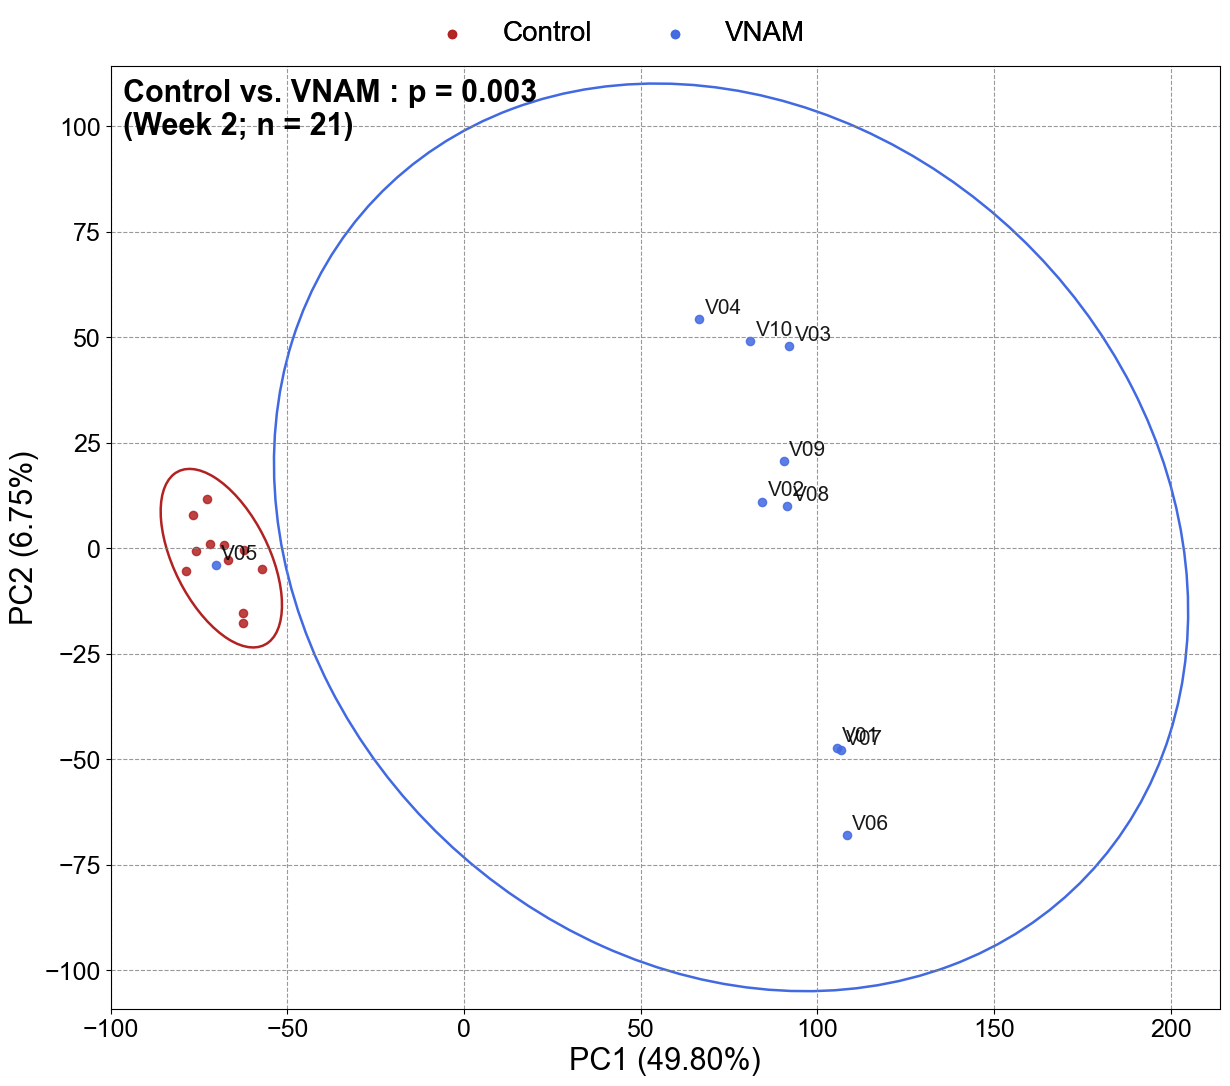

In [71]:
# 6) Plot
# cal_ellipse가 요구하는 형태로 score df 생성
pc_df = pd.DataFrame({"Component1": pc1, "Component2": pc2, "Group": y.values})

color_map = {group1: "firebrick", group2: "royalblue", "QC": "green"}  #Edit

fig, ax = plt.subplots(figsize=(12.4, 10.4))

for g in y.unique():
    idx = (y == g).values
    col = color_map.get(g, "gray")

    ax.scatter(pc1[idx], pc2[idx], s=35, alpha=0.85, color=col,
#               edgecolors=col,
               label=g)

    # (선택) 95% 타원
#    col = sc.get_facecolor()[0]
    # 타원(공분산 기반)
    if idx.sum() >= 3:  ## 표본 너무 적으면 스킵
        (mx, my), w, h, ang = cal_ellipse(pc_df, g, component1="Component1", componet2="Component2", cl=0.95  ## 0.90 / 0.95 / 0.8 중 선택
                                          )
        ell = Ellipse((mx, my), width=w, height=h, angle=ang, facecolor="none", edgecolor=col, linewidth=1.8, zorder=0)
        ax.add_patch(ell)

#ax.axhline(0, linewidth=0.8)
#ax.axvline(0, linewidth=0.8)

plt.xlabel(f'PC1 ({evr[0]:.2f}%)', fontsize=22)
plt.ylabel(f'PC2 ({evr[1]:.2f}%)', fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

#ax.legend(frameon=True)
#ax.set_title("PCA of Metabolomics (colored by Group)")

ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.8, color="gray", alpha=0.8)


# --- (B) 2 Legneds: Group legend + p-value legend ---
# 1) Group legend
leg_groups = fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.98),  ## 위쪽 중앙
                        ncol=len(y.unique()), frameon=False, fontsize=20)
ax.add_artist(leg_groups)

# 2) p-value legend
leg = ax.legend([], [],  # 핸들/라벨 없이 title만
                title=p_title, loc="upper left", frameon=False, title_fontsize=22)
leg.get_title().set_fontweight('bold')

# Sample annotation: 원하는 그룹만 표시
#label_groups = ['Control']          # Control만
label_groups = ['VNAM']             # VNAM만
#label_groups = ['Control', 'VNAM']  # 둘 다

sample_labels = X.index.astype(str).str.replace(r"_\d+w$", "", regex=True)

for x_coord, y_coord, label, group in zip(pc1, pc2, sample_labels, y.values):
    if group in label_groups:
        ax.annotate(
            label,
            xy=(x_coord, y_coord),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=15,
            alpha=0.9
        )

plt.tight_layout()
plt.savefig(f'pca_{WEEK}_annot.png', dpi=500, bbox_inches='tight')
plt.show()

In [117]:
## PCA with raw intensity Data

In [118]:
cd C:\Users\tr432\Downloads\Metabolomics_GutLungAxis_re-pipeline\weeks_merged_for_pca

C:\Users\tr432\Downloads\Metabolomics_GutLungAxis_re-pipeline\weeks_merged_for_pca


In [119]:
STYPE = 'serum_pos'

group1 = 'Control'
group2 = 'VNAM'

In [120]:
df = pd.read_excel('dataset_filtered_scaled_merged.xlsx', sheet_name=STYPE, index_col='Label')
df = df.transpose()
df.tail(3)

Label,Group,61.03969-1.062,496.33995-14.389,172.07169-4.382,520.34-13.811,73.06478-1.434,79.02112-1.1,203.05255-1.03,522.35575-14.699,132.1019-1.822,...,596.29997-13.718,437.22062-12.514,674.89818-0.956,288.86105-0.885,277.20115-13.158,363.27442-15.162,316.18052-7.669,290.8553-0.999,361.88999-0.954,243.88082-0.929
V08_2w,VNAM,0.497941,-0.209149,1.780156,-0.32948,0.599358,2.091117,-0.354245,-0.551513,0.633547,...,0.170254,0.883483,0.702344,0.643284,1.292119,-1.834075,-1.0251,-0.091088,0.029777,-0.882815
V09_2w,VNAM,-0.112643,0.065322,2.175284,0.304756,0.406867,-1.664734,0.240324,0.392965,0.469236,...,-1.358197,0.690029,0.448169,0.135704,-1.028878,0.887216,1.534252,0.355426,0.271929,0.058032
V10_2w,VNAM,-0.118791,0.09293,1.841064,0.294317,0.496079,-1.664734,0.079731,0.232903,0.381165,...,0.556288,-2.047955,0.46172,0.53293,1.851131,-1.834075,-1.0251,-0.234898,-1.206897,0.34642


In [121]:
#df = df[df['Group'] != 'QC'].copy()  #Edit: 주석처리 하거나 풀거나
df.tail(3)

Label,Group,61.03969-1.062,496.33995-14.389,172.07169-4.382,520.34-13.811,73.06478-1.434,79.02112-1.1,203.05255-1.03,522.35575-14.699,132.1019-1.822,...,596.29997-13.718,437.22062-12.514,674.89818-0.956,288.86105-0.885,277.20115-13.158,363.27442-15.162,316.18052-7.669,290.8553-0.999,361.88999-0.954,243.88082-0.929
V08_2w,VNAM,0.497941,-0.209149,1.780156,-0.32948,0.599358,2.091117,-0.354245,-0.551513,0.633547,...,0.170254,0.883483,0.702344,0.643284,1.292119,-1.834075,-1.0251,-0.091088,0.029777,-0.882815
V09_2w,VNAM,-0.112643,0.065322,2.175284,0.304756,0.406867,-1.664734,0.240324,0.392965,0.469236,...,-1.358197,0.690029,0.448169,0.135704,-1.028878,0.887216,1.534252,0.355426,0.271929,0.058032
V10_2w,VNAM,-0.118791,0.09293,1.841064,0.294317,0.496079,-1.664734,0.079731,0.232903,0.381165,...,0.556288,-2.047955,0.46172,0.53293,1.851131,-1.834075,-1.0251,-0.234898,-1.206897,0.34642


In [122]:
# 1) y, X 분리
y = df.iloc[:, 0].astype(str)     # Group
X = df.iloc[:, 1:].copy()         # peak area들

# 2) ✅ 이번 에러 핵심: 컬럼명이 str/float 섞임 → 전부 문자열로 통일
X.columns = X.columns.map(str)

# (선택) 비정상 헤더 제거(빈 헤더/Unnamed가 섞인 경우)
X = X.loc[:, ~X.columns.str.match(r"^Unnamed")]
X = X.loc[:, X.columns != "nan"]

# 3) 숫자화 + 결측 처리
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")                 # 전부 NA인 feature 제거
X = X.fillna(X.median(numeric_only=True))       # 중앙값 대치

# 4) (선택) 스케일링 (스케일링을 안한 데이터라면)
#Xz = StandardScaler().fit_transform(X)
Xz = X.copy()

In [123]:
# 5) PCA
pca = PCA(n_components=2, random_state=0)
PC = pca.fit_transform(Xz)
pc1, pc2 = PC[:, 0], PC[:, 1]
evr = pca.explained_variance_ratio_ * 100

In [124]:
# k 선택: 예) 누적 설명분산 80%까지
pca_full = PCA(n_components=min(X.shape[0]-1, X.shape[1]), random_state=0)
PC_all = pca_full.fit_transform(Xz)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k = int(np.searchsorted(cum, 0.80) + 1)   # 80% 기준 (원하면 0.90 등으로 변경)

PCk = PC_all[:, :k]  # PC1..PCk

# Control/VNAM만
mask = y.isin([group1, group2]).values
labs = y.values[mask]
Z = PCk[mask]

Zc = Z[labs == group1]
Zv = Z[labs == group2]

# 조건: (각 그룹 n > k) & (n1+n2-2 > k) 정도는 만족해야 안정적
t2, fval, p_group, S = hotelling_t2(Zc, Zv)

p_txt = f'{p_group:.3e}' if p_group < 0.001 else f'{p_group:.3f}'
p_title = f'{group1} vs. {group2} : p = {p_txt}\n(Week {WEEK}; n = {mask.sum()})'

print(f'PC 1 ~ PC {k} = {cum[k-1]*100:.2f} %')

PC 1 ~ PC 11 = 82.11 %


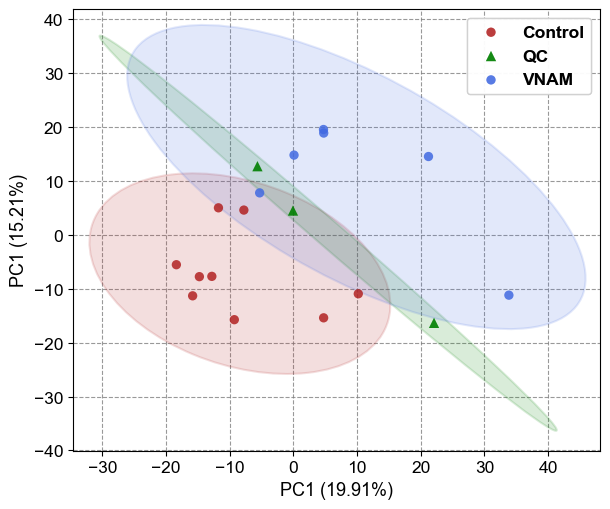

In [125]:
pc_df = pd.DataFrame({'Component1': pc1, 'Component2': pc2, 'Group': y.values})

colors  = {group1: 'firebrick', group2: 'royalblue', 'QC': 'green'}
markers = {group1: 'o', group2: 'o', 'QC': '^'}

orders = ['Control', 'VNAM', 'QC']

DRAW_QC_ELLIPSE = True  ## QC ellipse까지 그리고 싶으면 True
CI = 0.95  #Edit: 0.90 / 0.95 / 0.8

fig, ax = plt.subplots(figsize=(6.2, 5.2))

# 점
for g in y.unique():
    idx = (y == g).values
    col = color_map.get(g, 'gray')

    ax.scatter(pc1[idx], pc2[idx], s=55 if g == 'QC' else 45, alpha=0.9 if g == 'QC' else 0.85, c=colors.get(g, 'gray'), marker=markers.get(g, 'o'), edgecolors='none', label=g, zorder=3)

# ellipse (기본은 group1/group2 만)
for g in y.unique():
    idx = (y == g).values
    col = color_map.get(g, 'gray')

    if g in [group1, group2] or (DRAW_QC_ELLIPSE and g == 'QC'):
        (mx, my), w, h, ang = cal_ellipse(pc_df, g, component1='Component1', componet2='Component2', cl=CI)
        ell = Ellipse((mx, my), width=w, height=h, angle=ang, edgecolor=colors.get(g, 'gray'), facecolor=colors.get(g, 'gray'), linewidth=1.5, alpha=0.15, zorder=2)
        ax.add_patch(ell)

plt.xlabel(f'PC1 ({evr[0]:.2f}%)', fontsize=13)
plt.ylabel(f'PC1 ({evr[1]:.2f}%)', fontsize=13)

plt.xticks(fontsize=12.5)
plt.yticks(fontsize=12.5)

ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.8, color="gray", alpha=0.8)

# 1) Group legend
leg_groups = ax.legend(frameon=True, prop = {'size': 12.5, 'weight': 'bold'})
ax.add_artist(leg_groups)

# 2) p-value legend
#if p_title is not None:
#    ax.legend([], [], title=p_title, loc='lower left', frameon=False, title_fontsize=11)

plt.tight_layout()
plt.savefig("pca_merged.png", dpi=500, bbox_inches='tight')
plt.show()